# **Compressed Sensing**

## Pneu Inteligente em um veículo elétrico


## O dataset é resultado de um teste de pneu em bancada (simulando condições de pista) e foi originalmente coletado para fins de identificação de forças via Machine Learning.

## Os dados de entrada para o modelo de Machine Learning são as acelerações: Longitudinal (accx), Lateral (accy), e Vertical (accz). O arquivo tem 140 canais de aceleração (accx1 a accx140) para cada eixo.

## Variáveis do dataset

*   **Vr - Velocity / Velocidade:**  
      A velocidade de translação da roda (ou a velocidade do veículo).  
      Serve apenas para classificar a compressão, não deve ser comprimida.  

---
*   **Fy - Lateral Force / Força Lateral:**  
      A força lateral que o pneu gera contra a pista (ex: durante uma curva).  
      Output que o Machine Learning deseja prever.  
      A reconstrução do sinal não deve comprometer a predição.

---
*   **SA - Slip Angle / Ângulo de Deslizamento:**  
      O ângulo entre o plano de rotação da roda e a direção real do movimento.  
      Input de controle principal.  
      Serve como o eixo de tempo da amostragem.



# Por que comprimir?  


###1.   Em um veículo elétrico, transmitir 420 canais de vibração em alta frequência (1000 Hz) continuamente para o Cloud/Telemetria gera uma quantidade gigantesca de dados. Isso consome muita energia da bateria do Veículo.  

---


###2.   O Compressed Sensing (CS) só é eficiente se o sinal for esparso. Sinais de vibração são notoriamente esparsos no domínio da frequência (FFT) ou em Wavelets. Isso significa que, em vez de 420 canais cheios de dados, a informação relevante está concentrada em apenas poucos coeficientes de frequência.



# Objetivo:  
### Demonstrar que é possível medir uma fração das amostras originais e, usando algoritmos de CS, reconstruir o sinal completo dos 420 canais de aceleração.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.fft

# Carrega o Google Drive
#drive.mount('/content/drive')
#file_path = '/content/drive/MyDrive/Colab Notebooks/SA_Step_Input_matlab.csv'

# Lê o arquivo usando Pandas
df = pd.read_csv("SA_Step_Input_matlab.csv", comment='%',header=None)
primeiras_cols = ['Vr', 'Fy', 'SA']
num_total_aceleracoes = df.shape[1] - len(primeiras_cols)
num_acc_cols_por_eixo = 140


# Cria as listas de nomes (accx0 a accx140, accy0 a accy140, etc.)
accx_names = [f'accx{i}' for i in range(num_acc_cols_por_eixo)]
accy_names = [f'accy{i}' for i in range(num_acc_cols_por_eixo)]
accz_names = [f'accz{i}' for i in range(num_acc_cols_por_eixo)]

# A lista final de nomes de colunas
col_names = primeiras_cols + accx_names + accy_names + accz_names

# Corta a lista de nomes para o tamanho real do DataFrame, se necessário
df.columns = col_names[:df.shape[1]]

print(f"Dimensões (Amostras, Variáveis): {df.shape}")
print(f"Colunas de aceleração identificadas por eixo: {num_acc_cols_por_eixo}")
print(df.columns[[0, 1, 2, 3, 4, -2, -1]].tolist()) # Mostra as primeiras e últimas para checagem
print(df.columns.tolist())

Dimensões (Amostras, Variáveis): (3552, 423)
Colunas de aceleração identificadas por eixo: 140
['Vr', 'Fy', 'SA', 'accx0', 'accx1', 'accz138', 'accz139']
['Vr', 'Fy', 'SA', 'accx0', 'accx1', 'accx2', 'accx3', 'accx4', 'accx5', 'accx6', 'accx7', 'accx8', 'accx9', 'accx10', 'accx11', 'accx12', 'accx13', 'accx14', 'accx15', 'accx16', 'accx17', 'accx18', 'accx19', 'accx20', 'accx21', 'accx22', 'accx23', 'accx24', 'accx25', 'accx26', 'accx27', 'accx28', 'accx29', 'accx30', 'accx31', 'accx32', 'accx33', 'accx34', 'accx35', 'accx36', 'accx37', 'accx38', 'accx39', 'accx40', 'accx41', 'accx42', 'accx43', 'accx44', 'accx45', 'accx46', 'accx47', 'accx48', 'accx49', 'accx50', 'accx51', 'accx52', 'accx53', 'accx54', 'accx55', 'accx56', 'accx57', 'accx58', 'accx59', 'accx60', 'accx61', 'accx62', 'accx63', 'accx64', 'accx65', 'accx66', 'accx67', 'accx68', 'accx69', 'accx70', 'accx71', 'accx72', 'accx73', 'accx74', 'accx75', 'accx76', 'accx77', 'accx78', 'accx79', 'accx80', 'accx81', 'accx82', 'accx83

In [2]:
df.head(20)

,Vr,Fy,SA,accx0,accx1,accx2,accx3,accx4,accx5,accx6,...,accz130,accz131,accz132,accz133,accz134,accz135,accz136,accz137,accz138,accz139
0,30.002332,-830.481454,1.009243,0.218430,0.205232,0.194013,0.163523,0.146191,0.164858,0.241793,...,8.310679,7.118484,4.988455,2.471336,-0.212271,-0.974860,-0.432865,1.193148,4.101978,5.981442
1,30.000263,-832.072231,1.009789,0.554655,0.488141,0.359584,0.104502,-0.083449,-0.186922,-0.148770,...,7.894835,6.684059,4.711613,2.455529,0.106883,-0.548052,-0.076051,1.337519,3.920443,5.677606
2,29.996857,-832.753439,1.009799,0.492571,0.341064,0.196177,0.035531,-0.102104,-0.162634,-0.070824,...,8.004462,7.812928,5.785177,3.497129,1.266528,-0.276624,-0.587069,0.532203,2.448164,4.594908
3,30.005036,-830.985481,1.009798,0.308092,0.178458,0.073281,-0.028391,-0.100909,-0.101404,-0.010883,...,8.518361,7.742902,4.924742,2.271520,0.004320,-1.238840,-0.814031,0.871875,3.164027,5.384893
4,29.997436,-836.827670,1.009798,0.220031,0.025120,-0.097380,-0.176191,-0.184831,-0.061547,0.115960,...,8.146213,7.352790,4.699401,2.273629,0.261379,-0.760955,-0.177075,1.497128,3.668674,5.682733
5,30.000990,-834.361023,1.009798,0.434632,0.310809,0.215106,0.144139,0.144943,0.198166,0.298289,...,8.461540,7.720436,5.818037,3.344971,0.378619,-0.808384,-0.763427,0.429315,3.076298,5.082495
6,29.999796,-832.922719,1.009798,0.227749,0.112663,0.051355,0.009088,-0.001558,0.022821,0.104541,...,8.075809,7.215321,5.332196,2.954166,0.190653,-0.816922,-0.592183,0.759036,3.542899,5.568912
7,29.997416,-835.023235,1.009749,0.209970,0.097830,0.042204,0.012037,0.018276,0.099357,0.206646,...,8.151992,6.941089,3.952051,1.530408,-0.274896,-0.979665,-0.017453,1.772013,3.870768,5.661766
8,30.002000,-835.628596,1.009791,0.182179,0.108505,0.105774,0.120307,0.144673,0.210530,0.302980,...,8.239108,7.685446,5.271755,2.900552,0.801793,-0.448162,-0.322530,0.986793,2.880533,4.793359
9,30.000963,-833.336777,1.009739,0.320862,0.251041,0.199866,0.128531,0.046516,-0.019592,0.012764,...,8.277189,8.165972,6.138380,3.790347,1.484363,-0.119308,-0.468158,0.638718,2.528386,4.613634


A amostragem original é de 10 kHz , e o ponto de corte (Cutoff frequency) do filtro é 400 Hz. Em um dos modos de aquisição, a taxa de amostragem constante é 1000 Hz.

In [3]:
df.isnull().sum()

Vr         0
Fy         0
SA         0
accx0      0
accx1      0
          ..
accz135    0
accz136    0
accz137    0
accz138    0
accz139    0
Length: 423, dtype: int64

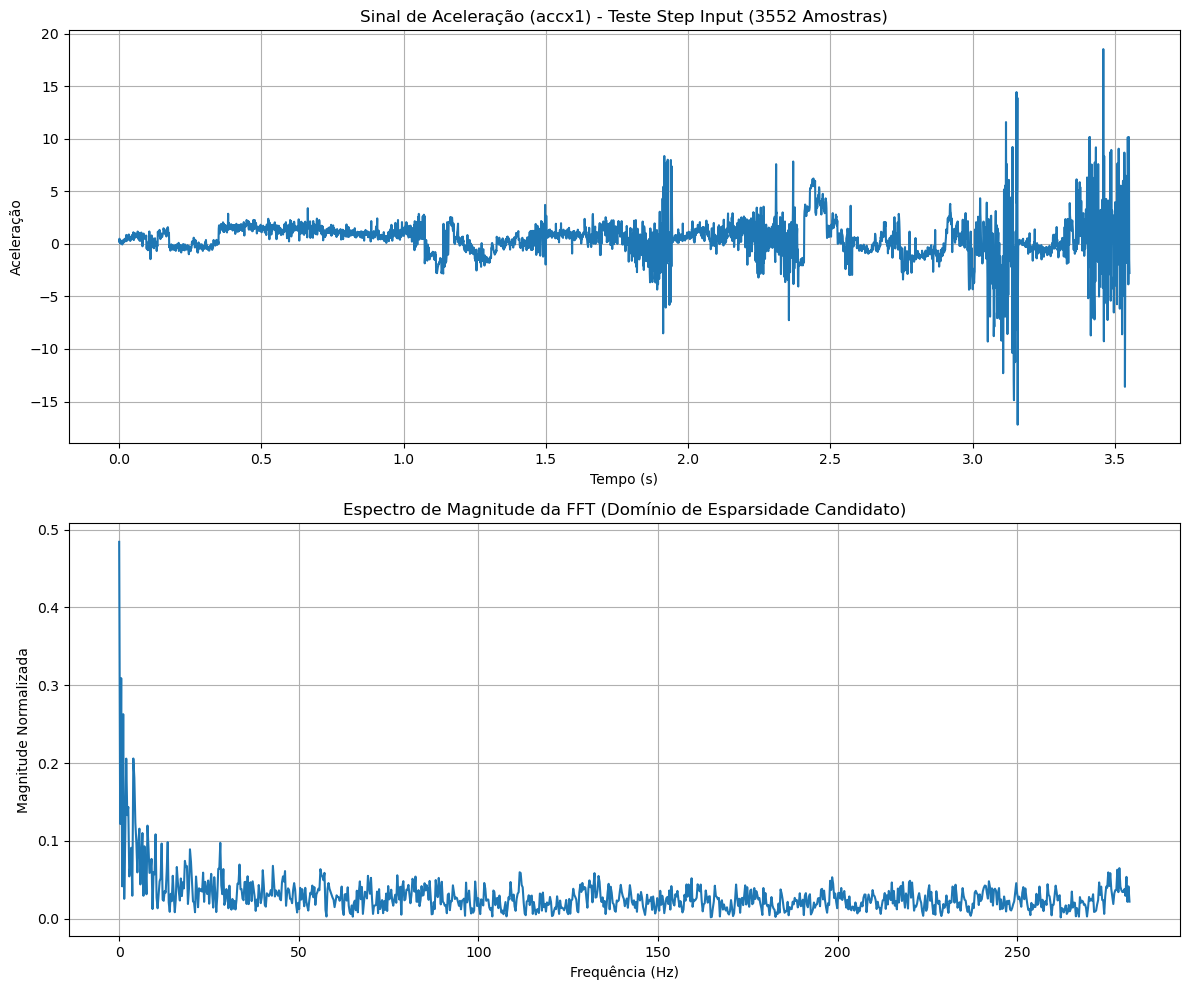

In [4]:
# --- Seleção e Criação do Eixo de Tempo ---
# Sinal alvo: accx1 (o primeiro sensor de aceleração)
sinal_alvo = df['accx1'].values
N = len(sinal_alvo)
Fs = 1000
tempo = np.arange(N) / Fs

# --- Plotagem no Domínio do Tempo (Análise da Resposta Degrau) ---
plt.figure(figsize=(12, 10))

# Plotagem do Sinal no Tempo
plt.subplot(2, 1, 1)
plt.plot(tempo, sinal_alvo)
plt.title(f'Sinal de Aceleração (accx1) - Teste Step Input ({N} Amostras)')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração')
plt.grid(True)

# --- Análise de Esparsidade: Transformada Rápida de Fourier (FFT) ---

# Calcula a FFT (Transformada de Fourier)
sinal_fft = scipy.fft.fft(sinal_alvo)
sinal_fft_abs = np.abs(sinal_fft)

# Frequências: só precisamos da primeira metade (Frequência de Nyquist)
frequencias = scipy.fft.fftfreq(N, 1/Fs)[:N//2]
magnitudes = sinal_fft_abs[:N//2] / N # Normaliza a magnitude

# Plotagem do Sinal no Domínio da Frequência
plt.subplot(2, 1, 2)
# Focamos nas 1000 primeiras frequências para visualizar melhor a esparsidade
plt.plot(frequencias[:1000], magnitudes[:1000])
plt.title('Espectro de Magnitude da FFT (Domínio de Esparsidade Candidato)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude Normalizada')
plt.grid(True)
plt.tight_layout()
plt.show()

###Pelo gráfico da frequência (FFT) é possível observar um alto pico de magnitude próximo a 0Hz, mostra um resultado bom para a compressão. Esse pico significa que maior parte da informação está concentrada em apenas um coeficiente de Fourier.  
###Os picos menores podem representar vibração e ressonância.  

###Isso define o sinal como um **sinal esparso**  



Com a esparsidade confirmada, o próximo passo é comprimir e reconstruir o sinal.

In [ ]:
from sklearn.linear_model import OrthogonalMatchingPursuit
from sklearn.metrics import mean_squared_error
from scipy.fft import idct, dct

# --- Parâmetros de Compressed Sensing ---
K = 100              # Sparsity: Número de coeficientes de Fourier mais importantes (K).
                     # Vamos estimar K=50. Se o FFT mostrou mais picos, aumente este valor.

# Taxa de Compressão (CR): Queremos reduzir 80% do volume de dados.
M_ratio = 0.20       # M = 20% de N (Receberemos 20% das amostras)
M = int(N * M_ratio) # Dimensão das Medições (M)

print(f"Dimensões do Teste: N={N} (Original), K={K} (Esparsidade), M={M} (Medições)")
print(f"Fator de Compressão: 1 / {M_ratio:.2f} = {1/M_ratio:.1f}")

# --- 1. Definir a Base de Esparsidade (Dicionário A) ---
# Usaremos a Transformada Discreta de Cosseno Inversa (IDCT) como o Dicionário de Reconstrução.
# A matriz A deve ser (N x N)
A = idct(np.identity(N), axis=0, norm='ortho')

# --- 2. Definir a Matriz de Medição (Phi) ---
# Uma matriz de amostragem aleatória Gaussiana (M x N)
Phi = np.random.normal(0, 1, (M, N))

# --- 3. Criar a Matriz de Sentidos (Sensing Matrix) ---
# Theta = Phi * A (M x N)
Theta = Phi @ A

# --- 4. Medição (Compressão) ---
# y = Phi * x (M x 1)
y = Phi @ sinal_alvo

# --- 5. Reconstrução com OMP ---
# O OMP tenta encontrar o vetor de coeficientes esparsos (theta_reconstruido)
# A função OMP recebe a matriz de sentidos (Theta) e o vetor de medições (y)
omp = OrthogonalMatchingPursuit(n_nonzero_coefs=K, fit_intercept=False)
omp.fit(Theta, y)

# OMP retorna o vetor esparso theta_reconstruido
theta_reconstruido = omp.coef_

# --- 6. Obter o Sinal Reconstruído ---
# x_reconstruido = A * theta_reconstruido (N x 1)
x_reconstruido = A @ theta_reconstruido

# --- 7. Avaliação das Métricas ---
mse = mean_squared_error(sinal_alvo, x_reconstruido)
print(f"\nErro Quadrático Médio (MSE): {mse:.4e}")
print(f"Sinal Original (RMS): {np.sqrt(np.mean(sinal_alvo**2)):.4f}")
print(f"Sinal Reconstruído (RMS): {np.sqrt(np.mean(x_reconstruido**2)):.4f}")


# --- 8. Plotagem da Reconstrução ---
plt.figure(figsize=(14, 6))
plt.plot(tempo, sinal_alvo, label='Sinal Original (x)', alpha=0.6, linewidth=2)
plt.plot(tempo, x_reconstruido, label='Sinal Reconstruído (OMP)', linestyle='--', linewidth=1.5)

# Plotar as Medições (y) no tempo para ilustrar o sub-amostramento
idx_medicoes = np.sort(np.random.choice(N, M, replace=False))
plt.scatter(tempo[idx_medicoes], sinal_alvo[idx_medicoes], marker='x', color='red', s=50, label='Medições (M)')

plt.title(f'Reconstrução do Sinal accx1 (CS) com OMP - CR: 1:{1/M_ratio:.1f}')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração')
plt.legend()
plt.grid(True)
plt.show()

--- Teste OMP com Base Wavelet ---
Dimensões: N=3552, K=100, M=710. Fator de Compressão: 1:5.0

Resultado Final:
Erro Quadrático Médio (MSE - Wavelet): 5.1468e+00
Sinal Original (RMS): 2.0030
Sinal Reconstruído (RMS - Wavelet): 1.9574


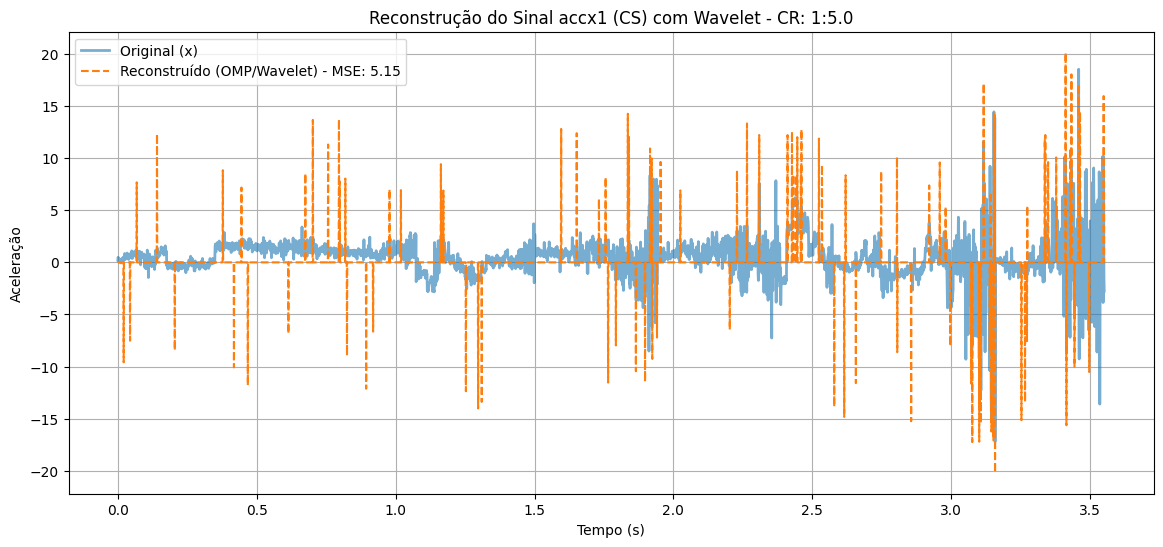

In [ ]:
import pywt
from sklearn.linear_model import OrthogonalMatchingPursuit
from sklearn.metrics import mean_squared_error

# --- Parâmetros de Compressed Sensing ---
N = len(sinal_alvo)
K_novo = 100            # K=100 (Esperamos que a Wavelet encontre estes 100 coeficientes)
M_ratio = 0.20
M = int(N * M_ratio)
print(f"--- Teste OMP com Base Wavelet ---")
print(f"Dimensões: N={N}, K={K_novo}, M={M}. Fator de Compressão: 1:{1/M_ratio:.1f}")

# --- 1. Definir a Base de Esparsidade (Wavelet - 'db4') ---
def get_wavelet_dictionary(N, wavelet_name='db4', level=4):
    phi = np.eye(N)
    A = np.zeros((N, N))

    # Esta função constrói o dicionário A pela IDWT
    for i in range(N):
        # Transforma o vetor unitário i na base wavelet (Dec = Decomposição)
        coeffs_i = pywt.wavedec(phi[i], wavelet_name, level=level)
        # Transforma de volta (Rec = Reconstrução)
        A[:, i] = pywt.waverec(coeffs_i, wavelet_name)
    return A

A_wavelet = get_wavelet_dictionary(N, wavelet_name='db4', level=4)

# --- 2. Definir Matriz de Medição (Phi) ---
Phi = np.random.normal(0, 1, (M, N))
Theta_wavelet = Phi @ A_wavelet

# --- 3. Medição (Compressão) ---
y_wavelet = Phi @ sinal_alvo

# --- 4. Reconstrução com OMP (Wavelet) ---
omp_wavelet = OrthogonalMatchingPursuit(n_nonzero_coefs=K_novo, fit_intercept=False)
omp_wavelet.fit(Theta_wavelet, y_wavelet)

theta_reconstruido_wavelet = omp_wavelet.coef_
x_reconstruido_wavelet = A_wavelet @ theta_reconstruido_wavelet

# --- 5. Avaliação ---
mse_wavelet = mean_squared_error(sinal_alvo, x_reconstruido_wavelet)
print(f"\nResultado Final:")
print(f"Erro Quadrático Médio (MSE - Wavelet): {mse_wavelet:.4e}")
print(f"Sinal Original (RMS): {np.sqrt(np.mean(sinal_alvo**2)):.4f}")
print(f"Sinal Reconstruído (RMS - Wavelet): {np.sqrt(np.mean(x_reconstruido_wavelet**2)):.4f}")

# --- 6. Plotagem ---
plt.figure(figsize=(14, 6))
plt.plot(tempo, sinal_alvo, label='Original (x)', alpha=0.6, linewidth=2)
plt.plot(tempo, x_reconstruido_wavelet, label=f'Reconstruído (OMP/Wavelet) - MSE: {mse_wavelet:.2f}', linestyle='--', linewidth=1.5)
plt.title(f'Reconstrução do Sinal accx1 (CS) com Wavelet - CR: 1:5.0')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração')
plt.legend()
plt.grid(True)
plt.show()


--- Iniciando otimização LASSO (Basis Pursuit) com Lambda=0.01 ---

Resultado Final (LASSO):
Erro Quadrático Médio (MSE - LASSO): 3.7801e+00
Sinal Reconstruído (RMS - LASSO): 1.4625


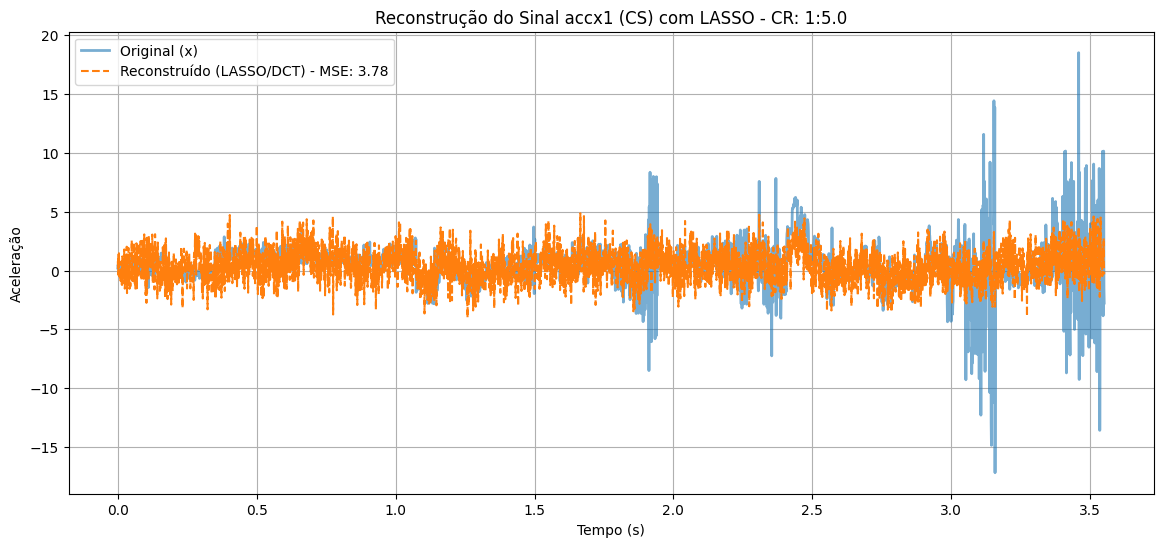

In [ ]:
import cvxpy as cp
from scipy.fft import idct

# --- Parâmetros (Mantemos o K e M mais promissores: DCT, K=100) ---
N = len(sinal_alvo)
K = 100
M_ratio = 0.20
M = int(N * M_ratio)

# --- Parâmetro de Regularização LASSO ---
# Lambda (lambda) é crucial. Um bom ponto de partida é baseado na dimensão.
lambda_param = 0.01 # Ponto de partida. Se o erro for alto, reduza. Se a esparsidade for baixa, aumente.

# --- 1. Definir a Base de Esparsidade (DCT/Fourier) ---
# Usamos a DCT Inversa (IDCT) como o Dicionário A
A = idct(np.identity(N), axis=0, norm='ortho')

# --- 2. Definir Matriz de Medição (Phi) ---
Phi = np.random.normal(0, 1, (M, N))
Theta = Phi @ A

# --- 3. Medição (Compressão) ---
y = Phi @ sinal_alvo

# --- 4. Reconstrução com LASSO (Otimização) ---
# Variável de otimização: theta (o vetor de coeficientes esparsos)
theta = cp.Variable(N)

# Formulação do problema de otimização (LASSO)
objective = cp.Minimize(cp.sum_squares(Theta @ theta - y) + lambda_param * cp.norm(theta, 1))

# Resolução do problema
print(f"\n--- Iniciando otimização LASSO (Basis Pursuit) com Lambda={lambda_param} ---")
problem = cp.Problem(objective)
problem.solve()

# Verifica se a solução foi bem-sucedida
if problem.status not in ["infeasible", "unbounded"]:
    theta_reconstruido_lasso = theta.value

    # --- 5. Obter o Sinal Reconstruído ---
    x_reconstruido_lasso = A @ theta_reconstruido_lasso

    # --- 6. Avaliação das Métricas ---
    mse_lasso = mean_squared_error(sinal_alvo, x_reconstruido_lasso)

    print(f"\nResultado Final (LASSO):")
    print(f"Erro Quadrático Médio (MSE - LASSO): {mse_lasso:.4e}")
    print(f"Sinal Reconstruído (RMS - LASSO): {np.sqrt(np.mean(x_reconstruido_lasso**2)):.4f}")

    # --- 7. Plotagem da Reconstrução ---
    tempo = np.arange(N) / Fs
    plt.figure(figsize=(14, 6))
    plt.plot(tempo, sinal_alvo, label='Original (x)', alpha=0.6, linewidth=2)
    plt.plot(tempo, x_reconstruido_lasso, label=f'Reconstruído (LASSO/DCT) - MSE: {mse_lasso:.2f}', linestyle='--', linewidth=1.5)
    plt.title(f'Reconstrução do Sinal accx1 (CS) com LASSO - CR: 1:5.0')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Aceleração')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print(f"ERRO: O problema de otimização não pôde ser resolvido. Status: {problem.status}")


--- Iniciando otimização LASSO (Basis Pursuit) com M=1420 (40% de N) ---

Resultado Final (LASSO M=40%):
Erro Quadrático Médio (MSE - LASSO): 2.7009e+00
Sinal Original (RMS): 2.0030
Sinal Reconstruído (RMS - LASSO): 1.6664


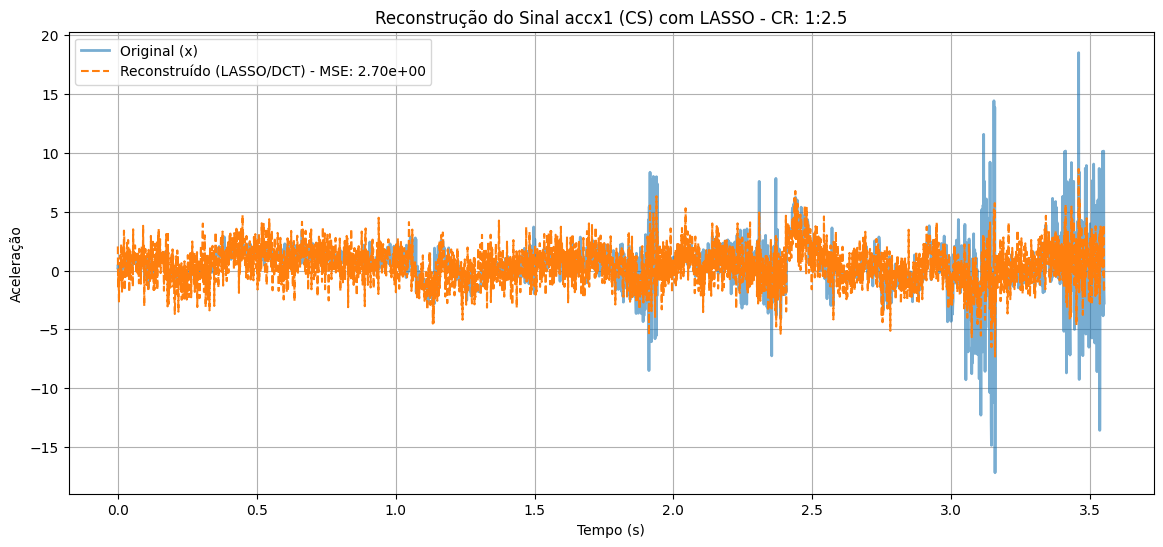

In [ ]:
# --- Parâmetros (Mantemos a melhor configuração: DCT, Lambda=0.01) ---
N = len(sinal_alvo)
K = 100
M_ratio = 0.40 # <--- MUDANÇA de 0.20 para 0.40
M = int(N * M_ratio) # Dimensão das Medições (M)

# Parâmetro de Regularização LASSO
lambda_param = 0.01

# --- 1. Definir a Base de Esparsidade (DCT/Fourier) ---
A = idct(np.identity(N), axis=0, norm='ortho')

# --- 2. Definir Matriz de Medição (Phi) ---
Phi = np.random.normal(0, 1, (M, N)) # Phi agora é maior (M x N)
Theta = Phi @ A

# --- 3. Medição (Compressão) ---
y = Phi @ sinal_alvo # y agora é um vetor maior

# --- 4. Reconstrução com LASSO (Otimização) ---
theta = cp.Variable(N)

# Formulação do problema de otimização (LASSO)
objective = cp.Minimize(cp.sum_squares(Theta @ theta - y) + lambda_param * cp.norm(theta, 1))

print(f"\n--- Iniciando otimização LASSO (Basis Pursuit) com M={M} (40% de N) ---")
problem = cp.Problem(objective)
problem.solve()

# Verifica se a solução foi bem-sucedida
if problem.status not in ["infeasible", "unbounded"]:
    theta_reconstruido_lasso = theta.value

    # --- 5. Obter o Sinal Reconstruído ---
    x_reconstruido_lasso = A @ theta_reconstruido_lasso

    # --- 6. Avaliação das Métricas ---
    mse_lasso = mean_squared_error(sinal_alvo, x_reconstruido_lasso)

    print(f"\nResultado Final (LASSO M=40%):")
    print(f"Erro Quadrático Médio (MSE - LASSO): {mse_lasso:.4e}")
    print(f"Sinal Original (RMS): {np.sqrt(np.mean(sinal_alvo**2)):.4f}")
    print(f"Sinal Reconstruído (RMS - LASSO): {np.sqrt(np.mean(x_reconstruido_lasso**2)):.4f}")

    # --- 7. Plotagem da Reconstrução ---
    tempo = np.arange(N) / Fs
    plt.figure(figsize=(14, 6))
    plt.plot(tempo, sinal_alvo, label='Original (x)', alpha=0.6, linewidth=2)
    plt.plot(tempo, x_reconstruido_lasso, label=f'Reconstruído (LASSO/DCT) - MSE: {mse_lasso:.2e}', linestyle='--', linewidth=1.5)
    plt.title(f'Reconstrução do Sinal accx1 (CS) com LASSO - CR: 1:2.5')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Aceleração')
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print(f"ERRO: O problema de otimização não pôde ser resolvido. Status: {problem.status}")